<a href="https://colab.research.google.com/github/dwililiya07/cifar10-architecture-experiments/blob/main/CNN_from_Scratch_on_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description

This project aims to implement a custom Convolutional Neural Network (CNN) architecture for image recognition without using any pre-trained models.In other words, the model will be built entirely from scratch.

The dataset used is CIFAR-10, which contains 60.000 RGB images (32x32 pixels) across 10 different classes.

The CNN architecture will be designed through experimentation, making this project a valuable opportunity to understand the impact of architectural choices and additional techniques that can improve model performance.

After conducting several experiments and identifying the best-performance model, I will build an inference pipeline so that others can test the model themselves. The user interface will be implemented using Gradio and I will upload to Hugging Face Space

This project will be developed using Python and PyTorch.



## Experiment Strategy

The model development followed an iterative improvement approach:

1. Establish a simple baseline CNN.
2. Improve generalization through data augmentation and normalization.
3. Increase representational capacity with deeper convolution blocks.
4. Apply training control mechanisms (scheduler and early stopping).

In [24]:
# Import Library
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# transform: normalization(0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [4]:
# dataset and dataloader
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 28.1MB/s]


## Experiment 1- Baseline Model

**Objective:**
Establish a simple convolutional neural network baseline to measure initial performance on CIFAR-10 before applying architectural and training improvements.

**Data Transformations (Augmentation):**
- To Tensor()
- Normalize(0.5)

**Model Architecture:**
- Conv blocks: 4 ->[32, 64, 128, 256]
- MaxPool2D after each block
- Activation: ReLU
- GAP: AdaptiveAvgPool2d(1) -> for reduce feature map dimension to a fixed size
- Flatten
- Fully Connected: Linear(256 -> 10 classes)

**Training Setup:**
- Optimizer: Adam
- Loss: CrossEntropyLoss (for multiclass)
- Epoch: 5
- Batch Size: 64





In [5]:
# build the model
class SimpleCNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

    self. pool = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()

    self.gap = nn.AdaptiveAvgPool2d(1)
    self.fc = nn.Linear(256, num_classes)


  def forward(self, x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))
    x = self.pool(self.relu(self.conv3(x)))
    x = self.pool(self.relu(self.conv4(x)))

    x = self.gap(x)             # [B, 256, 1, 1]
    x = x.view(x.size(0), -1)   # flatten → [B, 256]
    x = self.fc(x)

    return x

In [6]:
# setup model
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
for epoch in range(5):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()

      outputs = model(images)
      loss = criterion(outputs, labels)

      loss.backward()
      optimizer.step()

      running_loss += loss.item()

  print("Loss:", running_loss / len(train_loader))

  correct = 0
  total = 0

  model.eval()
  with torch.no_grad():
    for images, labels in train_loader:
      images, labels = images.to(device), labels. to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)

      total+= labels.size(0)
      correct += (predicted == labels).sum().item()

  print("Train Accuracy:", correct/total)

Loss: 1.5195934169585137
Train Accuracy: 0.5542
Loss: 1.0724690302711009
Train Accuracy: 0.67428
Loss: 0.8697642785356478
Train Accuracy: 0.69086
Loss: 0.7448252593464864
Train Accuracy: 0.77208
Loss: 0.6436388973156204
Train Accuracy: 0.8149


**RESULTS**

**Training Accuracy:** at 5 epochs, the accuracy hit 81.49%

**Validation Accuracy:** - (In this initial experiment, performance was evaluated only on the training dataset. Validation accuracy was not computed at this stage, limiting the ability to assess generalization performance.
This setup was later improved in subsequent experiments by introducing a proper validation loop.)

**Observations:**
- consistent loss decrease: training loss steadily decreased across epochs, indicating stable optimization.

- rapid early learning: the largest improvement occurred between Epoch 1 and Epoch 2, suggesting the model quickly captured low-level image features.

- slowing improvement after epoch 3: accuracy growth became less steep after the third epoch. This may indicate: limited representational capacity of the baseline, insufficient training duration, lack of regularization or augmentation.

- undertraining risk: since we try to stop at 5 epochs, the model likely had not fully converged.


**Notes:**
The baseline architecture is capable of learning meaningful patterns.However, without data augmentation and normalization tuned to CIFAR-10 statistics, generalization performance is expected to be limited. The model may begin overfitting if trained longer without regularization.



## Experiment 2 - Enhanced Model with Data Augmentation and Regularization

**Objective:**
Improve generalization and robustness of the CNN baseline by applying more data transformations and adding Batch Normalization and Dropout layers.

**Data Transformations (Augmentation):**
- RandomHorizontalFlip()
- RandomCrop(32, padding=4)
- ToTensor()
- Normalize(mean,std)

**Model Architecture:**
- Convolutional blocks: 4 -> [32, 64, 128, 256] filters
- BatchNorm after each convolutional layer
- Activation: ReLU
- pooling: MaxPool2D after each block
- Dropout (0.3) after fully connected layer
- GAP: AdaptiveAvgPool2d(1)
- Flatten
- Fully Connected: Linear(256 -> 10 classes)

**Training Setup:**  
- Optimizer: Adam  
- Loss Function: CrossEntropyLoss  
- Epochs: 10  
- Batch Size: 64

**Optimization:** BatchNorm

**Regularization:**
- Dropout
- Data augmentation

In [11]:
# transform: add more augmentation: flip, crop, normalize(mean,std)
# transform flip, crop, normalize
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435,  0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435,  0.2616))
])

In [12]:
# dataset and data loader
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [13]:
# build the model
class SimpleCNN2(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)     # add batch norm each layer

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(256)

    self. pool = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()


    self.gap = nn.AdaptiveAvgPool2d(1)
    self.dropout = nn.Dropout(0.3)
    self.fc = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.pool(self.relu(self.bn1(self.conv1(x))))
    x = self.pool(self.relu(self.bn2(self.conv2(x))))
    x = self.pool(self.relu(self.bn3(self.conv3(x))))
    x = self.pool(self.relu(self.bn4(self.conv4(x))))

    x = self.gap(x)             # [B, 256, 1, 1]
    x = x.view(x.size(0), -1)   # flatten → [B, 256]
    x = self.dropout(x)
    x = self.fc(x)

    return x

To facilitate experimentation and code efficiency, I created functions for training and testing.

In [14]:
# training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        _, preds = torch.max(outputs, 1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [15]:
# evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)

            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [16]:
# main training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN2(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, test_loader, criterion, device
    )

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

Epoch [1/10]
Train Loss: 1.3492 | Train Acc: 0.5116
Val   Loss: 1.1233 | Val   Acc: 0.5903
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.9955 | Train Acc: 0.6474
Val   Loss: 0.9609 | Val   Acc: 0.6627
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.8692 | Train Acc: 0.6933
Val   Loss: 0.9162 | Val   Acc: 0.6824
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.7874 | Train Acc: 0.7256
Val   Loss: 0.7311 | Val   Acc: 0.7472
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.7322 | Train Acc: 0.7449
Val   Loss: 0.7628 | Val   Acc: 0.7443
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.6858 | Train Acc: 0.7609
Val   Loss: 0.6940 | Val   Acc: 0.7639
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.6510 | Train Acc: 0.7743
Val   Loss: 0.6119 | Val   Acc: 0.7893
--------------------------------------------------
Epoch 

**Results:**
- Training Accuracy: best di epoch 9 yaitu 79.6%
- Validation Accuracy: best epoch 9 yaitu 80.5%

**Observation:**
- Train accuracy increased steadily from 51% to 80%
- Validation accuracy increased steadily from 59% to 80%.
- The gap was very small throughout training.

if we compared with experiment 1, experiment 2 make model more controller.

- accuracy training and validation not much different, even in epoch 1 val acc more higher than train acc. it because we use augmentation for images input. so training more difficult, that's mean model can learn feature more robust.

- Loss and accuracy fluctuate smoothly.
There are no extreme spikes. BatchNorm most likely helps with gradient stability. Without BatchNorm, training is usually noisier.

- But at epoch 7 to 10, growth begins to slow.

**Notes:**
The introduction of data augmentation significantly reduced the generalization gap observed in the baseline experiment. Training became more challenging due to stochastic transformations, resulting in validation accuracy occasionally exceeding training accuracy.
Batch normalization improved convergence stability, while dropout (p=0.3) provided sufficient regularization without causing underfitting.
The model achieved its best validation accuracy of 80.5% at epoch 9, indicating strong generalization performance compared to the baseline.

## Experiment 3 - Training Control and Double Convolution Blocks

**Objective:**
Prevent overfitting and improve model stability by adding learning rate scheduling, early stopping, and experimenting with double convolution blocks.

**Model Architecture:**  
- Double Convolution per block: Conv + Conv → BatchNorm → ReLU → Conv + Conv → BatchNorm → ReLU  
- Filters progression: [32, 64, 128, 256]  
- Pooling: MaxPool2D after each block  
- GAP: AdaptiveAvgPool2d(1)  
- Flatten  
- Fully Connected: Linear(256 → 10 classes)  
- Dropout (p=0.3) after fully connected layer

**Training Setup:**  
- Optimizer: Adam  
- Loss Function: CrossEntropyLoss  
- Epochs: 20  
- Batch Size: 64  
- Scheduler: CosineAnnealingLR  
- Early Stopping: patience=3 (stop training if validation loss does not improve for 3 epochs)

### start with 32 filters

In [18]:
# we use the same augmentation with experiment 2 but add more conv layer in model architecture
class SimpleCNN3(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)     # add batch norm each layer

    self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
    self.bn1b = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2b = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn3b = nn.BatchNorm2d(128)

    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(256)

    self.conv4b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn4b = nn.BatchNorm2d(256)


    self. pool = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()


    self.gap = nn.AdaptiveAvgPool2d(1)
    self.dropout = nn.Dropout(0.3)
    self.fc = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.relu(self.bn1(self.conv1(x)))
    x = self.relu(self.bn1b(self.conv1b(x)))
    x = self.pool(x)
    x = self.relu(self.bn2(self.conv2(x)))
    x = self.relu(self.bn2b(self.conv2b(x)))
    x = self.pool(x)
    x = self.relu(self.bn3(self.conv3(x)))
    x = self.relu(self.bn3b(self.conv3b(x)))
    x = self.pool(x)
    x = self.relu(self.bn4(self.conv4(x)))
    x = self.relu(self.bn4b(self.conv4b(x)))
    x = self.pool(x)

    x = self.gap(x)             # [B, 256, 1, 1]
    x = x.view(x.size(0), -1)   # flatten → [B, 256]
    x = self.dropout(x)
    x = self.fc(x)

    return x


In [19]:
# main training loop
model = SimpleCNN3(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

num_epochs = 20
best_acc = 0.0
patience = 3
epochs_without_improvement = 0

for epoch in range(num_epochs):

  train_loss, train_acc = train_one_epoch(
      model, train_loader, criterion, optimizer, device
  )

  val_loss, val_acc = evaluate(
      model, test_loader, criterion, device
  )

  scheduler.step(val_acc)
  current_lr = optimizer.param_groups[0]['lr']
  print(f"Current LR: {current_lr:.6f}")

  print(f"Epoch [{epoch+1}/{num_epochs}]")
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

  # Early Stopping
  if val_acc > best_acc:
      best_acc = val_acc
      epochs_without_improvement = 0
      torch.save(model.state_dict(), "best_model.pth")
      print("Best model saved.")
  else:
      epochs_without_improvement += 1
      print(f"No improvement for {epochs_without_improvement} epoch(s).")

  if epochs_without_improvement >= patience:
      print("Early stopping triggered.")
      break

  print("-" * 50)

/tmp/ipykernel_1058/1602506079.py:28: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_acc)


Current LR: 0.000991
Epoch [1/20]
Train Loss: 1.2997 | Train Acc: 0.5291
Val Loss: 1.1880 | Val Acc: 0.6123
Best model saved.
--------------------------------------------------
Current LR: 0.000987
Epoch [2/20]
Train Loss: 0.8508 | Train Acc: 0.7022
Val Loss: 0.7713 | Val Acc: 0.7379
Best model saved.
--------------------------------------------------
Current LR: 0.000986
Epoch [3/20]
Train Loss: 0.7015 | Train Acc: 0.7582
Val Loss: 0.7389 | Val Acc: 0.7485
Best model saved.
--------------------------------------------------
Current LR: 0.000985
Epoch [4/20]
Train Loss: 0.6119 | Train Acc: 0.7914
Val Loss: 0.6152 | Val Acc: 0.7906
Best model saved.
--------------------------------------------------
Current LR: 0.000984
Epoch [5/20]
Train Loss: 0.5575 | Train Acc: 0.8072
Val Loss: 0.5965 | Val Acc: 0.7976
Best model saved.
--------------------------------------------------
Current LR: 0.000984
Epoch [6/20]
Train Loss: 0.5078 | Train Acc: 0.8253
Val Loss: 0.5608 | Val Acc: 0.8150
Best mo

**Results:**

The introduction of double convolution blocks significantly improved validation performance, increasing best validation accuracy from ~80% to ~85%.
The model demonstrated stable convergence up to epoch 9, after which validation performance began to decline, indicating early signs of overfitting.
Early stopping successfully halted training at epoch 12, preserving the best-performing model (epoch 9).
The cosine learning rate schedule ensured smooth optimization without abrupt learning rate drops.

### with the same training setup, we want to compare if the model we set at first layer start with 64 filters [64, 128,256,512]

I wanted to experiment whether there would be any impact if we made the model have more filters and the final number of features was 512. 2 times more than before.

In [21]:
# build model
class SimpleCNN4(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(64)

    self.conv1b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn1b = nn.BatchNorm2d(64)

    self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(128)

    self.conv2b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn2b = nn.BatchNorm2d(128)

    self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(256)

    self.conv3b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn3b = nn.BatchNorm2d(256)

    self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(512)

    self.conv4b = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn4b = nn.BatchNorm2d(512)

    self.pool = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.gap = nn.AdaptiveAvgPool2d(1)
    self.dropout = nn.Dropout(0.3)
    self.fc = nn.Linear(512, num_classes)

  def forward(self, x):
    x = self.relu(self.bn1(self.conv1(x)))
    x = self.relu(self.bn1b(self.conv1b(x)))
    x = self.pool(x)
    x = self.relu(self.bn2(self.conv2(x)))
    x = self.relu(self.bn2b(self.conv2b(x)))
    x = self.pool(x)
    x = self.relu(self.bn3(self.conv3(x)))
    x = self.relu(self.bn3b(self.conv3b(x)))
    x = self.pool(x)
    x = self.relu(self.bn4(self.conv4(x)))
    x = self.relu(self.bn4b(self.conv4b(x)))
    x = self.pool(x)

    x = self.gap(x)             # [B, 512, 1, 1]
    x = x.view(x.size(0), -1)   # flatten -> [B, 512]
    x = self.dropout(x)
    x = self.fc(x)

    return x

In [22]:
# main training loop
model = SimpleCNN4(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

num_epochs = 20
best_acc = 0.0
patience = 3
epochs_without_improvement = 0

for epoch in range(num_epochs):

  train_loss, train_acc = train_one_epoch(
      model, train_loader, criterion, optimizer, device
  )

  val_loss, val_acc = evaluate(
      model, test_loader, criterion, device
  )

  scheduler.step(val_acc)
  current_lr = optimizer.param_groups[0]['lr']
  print(f"Current LR: {current_lr:.6f}")

  print(f"Epoch [{epoch+1}/{num_epochs}]")
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

  # Early Stopping
  if val_acc > best_acc:
      best_acc = val_acc
      epochs_without_improvement = 0
      torch.save(model.state_dict(), "best_model.pth")
      print("Best model saved.")
  else:
      epochs_without_improvement += 1
      print(f"No improvement for {epochs_without_improvement} epoch(s).")

  if epochs_without_improvement >= patience:
      print("Early stopping triggered.")
      break

  print("-" * 50)

/tmp/ipykernel_1058/2512839910.py:28: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_acc)


Current LR: 0.000997
Epoch [1/20]
Train Loss: 1.2870 | Train Acc: 0.5320
Val Loss: 0.9966 | Val Acc: 0.6541
Best model saved.
--------------------------------------------------
Current LR: 0.000997
Epoch [2/20]
Train Loss: 0.8081 | Train Acc: 0.7182
Val Loss: 0.8018 | Val Acc: 0.7196
Best model saved.
--------------------------------------------------
Current LR: 0.000996
Epoch [3/20]
Train Loss: 0.6581 | Train Acc: 0.7714
Val Loss: 0.5877 | Val Acc: 0.7951
Best model saved.
--------------------------------------------------
Current LR: 0.000996
Epoch [4/20]
Train Loss: 0.5657 | Train Acc: 0.8059
Val Loss: 0.5799 | Val Acc: 0.8033
Best model saved.
--------------------------------------------------
Current LR: 0.000996
Epoch [5/20]
Train Loss: 0.4994 | Train Acc: 0.8274
Val Loss: 0.5449 | Val Acc: 0.8191
Best model saved.
--------------------------------------------------
Current LR: 0.000996
Epoch [6/20]
Train Loss: 0.4491 | Train Acc: 0.8465
Val Loss: 0.4835 | Val Acc: 0.8365
Best mo

**Results (Experiment 3 with 64 Filters):**

The model achieved a best validation accuracy of 89.61%, while the final training accuracy reached 94.67%. The lowest validation loss recorded was 0.3365. The model continued improving until around epoch 18–19, with a performance gap between training and validation accuracy of about 4–5%.

**Observations:**

The learning process was stable. Training loss decreased consistently throughout the epochs, and validation loss also showed a downward trend with only minor fluctuations.

The model has not fully plateaued yet. Since the best model was still being saved at epochs 18 and 19, it suggests that there is still potential for further improvement.

There is mild overfitting, as the training accuracy is noticeably higher than the validation accuracy. However, the gap is not extreme and remains within a reasonable range.

Using 64 filters performed better than 32 filters. The increased model capacity allows stronger feature representation, which helped push the validation accuracy close to 90%.

**Notes:**

At this stage, the model has sufficient capacity and shows good generalization performance. What it needs now is minor adjustment in regularization and possibly longer training duration. It is not necessary to change the architecture again. The focus should now be on stabilizing and fine-tuning the current setup.

## Experiment 4 - Focus on stabilization and fine tuning

- Add more epoch because the model still improving at the end of training. also not yet fully converged

- set patience 5 in early stopping. it give model a chance to recover when val acc stagnan for a while

- add weight decay (1e-4) to reduce gap train-val, making training more stable, and reduce overfitting

note: we still use SimpleCNN4 for baseline. because this better than others

In [25]:
# main training loop with save model
# Model
model = SimpleCNN4(num_classes=10).to(device)

# Hyperparameter
num_epochs = 40
patience = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

best_acc = 0.0
epochs_without_improvement = 0
start_epoch = 0

# Resume if checkpoint exists
if os.path.exists("last_checkpoint.pth"):
    print("Loading checkpoint...")

    checkpoint = torch.load("last_checkpoint.pth", map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    epochs_without_improvement = checkpoint['epochs_without_improvement']

    print(f"Resuming from epoch {start_epoch}")

# Training loop
for epoch in range(start_epoch, num_epochs):

  train_loss, train_acc = train_one_epoch(
      model, train_loader, criterion, optimizer, device
  )

  val_loss, val_acc = evaluate(
      model, test_loader, criterion, device
  )

  scheduler.step()
  current_lr = optimizer.param_groups[0]['lr']

  print(f"Current LR: {current_lr:.6f}")
  print(f"Epoch [{epoch+1}/{num_epochs}]")
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
  print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early Stopping
  if val_acc > best_acc:
    best_acc = val_acc
    epochs_without_improvement=0
    torch.save({
        'model_state_dict': model.state_dict(),
        'val_acc': val_acc,
    }, "best_model_cnn_cifar.pth")
  else:
    epochs_without_improvement += 1
    print(f"No Improvement for {epochs_without_improvement} epoch(s)")

  # Save full checkpoint after updating state
  torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_acc': best_acc,
    'epochs_without_improvement': epochs_without_improvement
  }, "last_checkpoint.pth")

  if epochs_without_improvement >= patience:
    print("Early stopping triggered")
    break

  print("-" * 50)

Current LR: 0.000998
Epoch [1/40]
Train Loss: 1.3258 | Train Acc: 0.5174
Val Loss: 1.0159 | Val Acc: 0.6434
--------------------------------------------------
Current LR: 0.000994
Epoch [2/40]
Train Loss: 0.8559 | Train Acc: 0.7002
Val Loss: 0.7426 | Val Acc: 0.7441
--------------------------------------------------
Current LR: 0.000986
Epoch [3/40]
Train Loss: 0.6984 | Train Acc: 0.7587
Val Loss: 0.6939 | Val Acc: 0.7713
--------------------------------------------------
Current LR: 0.000976
Epoch [4/40]
Train Loss: 0.6087 | Train Acc: 0.7912
Val Loss: 0.5854 | Val Acc: 0.8022
--------------------------------------------------
Current LR: 0.000962
Epoch [5/40]
Train Loss: 0.5453 | Train Acc: 0.8138
Val Loss: 0.5487 | Val Acc: 0.8149
--------------------------------------------------
Current LR: 0.000946
Epoch [6/40]
Train Loss: 0.4942 | Train Acc: 0.8327
Val Loss: 0.5168 | Val Acc: 0.8254
--------------------------------------------------
Current LR: 0.000926
Epoch [7/40]
Train Loss: 

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:   # or val_loader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [31]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[928   6  19   5   6   3   5   2  19   7]
 [  5 963   0   0   1   1   0   0   4  26]
 [ 18   0 891  21  23  18  19   7   2   1]
 [ 10   1  23 845  18  72  21   3   4   3]
 [  3   0  13  18 937  13   5   9   1   1]
 [  4   1  11  72  17 877   5  10   0   3]
 [  5   1  15  13   7   9 947   0   2   1]
 [  6   0   7  17  13  18   0 935   1   3]
 [ 23   4   2   5   1   1   0   0 961   3]
 [ 10  23   2   2   0   0   2   2   9 950]]


In [32]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1000
           1       0.96      0.96      0.96      1000
           2       0.91      0.89      0.90      1000
           3       0.85      0.84      0.85      1000
           4       0.92      0.94      0.93      1000
           5       0.87      0.88      0.87      1000
           6       0.94      0.95      0.95      1000
           7       0.97      0.94      0.95      1000
           8       0.96      0.96      0.96      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



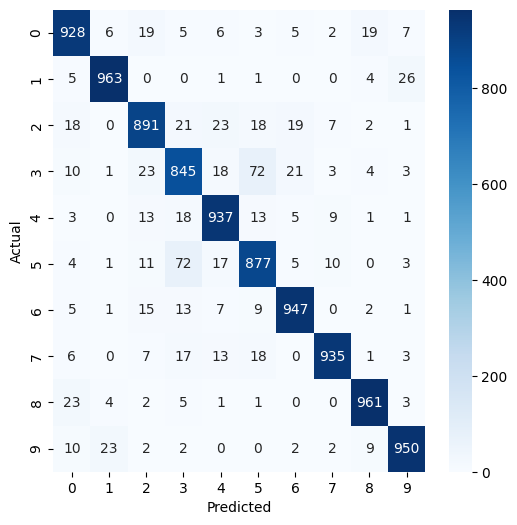

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model achieved an overall accuracy of 92% on a balanced test set, with consistent precision, recall, and F1-scores across all classes. Since each class contains the same number of samples, the accuracy metric is reliable and not biased by class imbalance. Most classes show strong performance, particularly classes 1, 7, 8, and 9, with precision and recall values above 0.95, indicating that the model can both correctly identify these classes and avoid misclassifying other classes as them.

However, classes 3 and 5 have slightly lower F1-scores, around 0.85–0.87, suggesting that the model occasionally confuses these categories with others. Despite this, the overall gap between training accuracy (around 94–95%) and test accuracy (92%) remains small, indicating good generalization and only mild overfitting.

In conclusion, the model demonstrates stable learning, balanced class performance, and strong generalization capability. While there is still room for improvement in certain classes, the current results reflect a well-optimized and reliable classification model.